# Greenhouse Signal Mapping — Diagnostic
Loads 4 rows, filters to size-34 packets, assigns grid labels from paper timestamps,
prints a removal report + per-cell summary, and plots 3 diagnostic charts.

**Put all 4 CSVs in the same folder as this notebook before running.**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── GEOMETRY ──────────────────────────────────────────────────────────────
GRID_LENGTH_M   = 15.0
GATEWAY_X       = 0.0    # TODO: update from floor plan
GATEWAY_Y       = 0.0    # gateway sits on the walking path
COLLECTION_DATE = '2026-06-25'
TIMEZONE        = '+02:00'
PACKET_SIZE     = 34
RSSI_GOOD       = -90
RSSI_WEAK       = -110

# Row name → x coordinate in meters (same x for mirrored pairs above/below path)
# TODO: replace 0.0 / 1.6 with real measurements from floor plan
ROW_GEOMETRY = {
    'R1354': {'x': -1.6},
    'R1356': {'x': 1.6},
}

# ── ROW CONFIG ────────────────────────────────────────────────────────────
# Negative G index = other side of the walking path (y negative)
ROW_CONFIG = {
    1: {
        'csv': '25-6_1354.csv',
        'timestamps': {
            'R1354_G1':  ('10:33:58', '10:38:30'),
            'R1354_G2':  ('10:38:30', '10:39:50'),
            'R1354_G3':  ('10:39:50', '10:41:15'),
            'R1354_G4':  ('10:41:15', '10:42:25'),
            'R1354_G5':  ('10:42:25', '10:43:30'),
            'R1354_G6':  ('10:43:30', '10:44:30'),
            'R1354_G7':  ('10:44:30', '10:45:35'),
            'R1354_G8':  ('10:45:35', '10:46:40'),
            'R1354_G9':  ('10:46:40', '10:47:40'),
            'R1354_G10': ('10:47:40', '10:48:40'),
        }
    },
    2: {
        'csv': '25-6_1356.csv',
        'timestamps': {
            'R1356_G1':   ('11:06:58', '11:09:35'),
            'R1356_G2':   ('11:09:35', '11:10:50'),
            'R1356_G3':   ('11:10:50', '11:11:50'),   # ??? check paper
            'R1356_G4':   ('11:11:50', '11:12:50'),
            'R1356_G5':   ('11:12:50', '11:13:50'),
            'R1356_G6':   ('11:13:50', '11:14:55'),
            'R1356_G7':   ('11:14:55', '11:15:55'),
            'R1356_G8':   ('11:15:55', '11:16:50'),   # ??? check paper
            'R1356_G9':   ('11:16:50', '11:18:05'),
            'R1356_G10':  ('11:18:05', '11:19:10'),
            'R1356_G11':  ('11:19:10', '11:20:30'),
            'R1356_G7_B': ('11:24:30', '11:27:00'),          # end time unreadable
        }
    },
    3: {
        'csv': '25-6_1185.csv',
        'timestamps': {
            'R1356_G-1':  ('11:36:25', '11:39:05'),
            'R1356_G-2':  ('11:39:05', '11:40:15'),
            'R1356_G-3':  ('11:40:15', '11:41:36'),
            'R1356_G-4':  ('11:41:36', '11:42:50'),
            'R1356_G-5':  ('11:42:50', '11:43:50'),
            'R1356_G-6':  ('11:43:50', '11:45:00'),
            'R1356_G-7':  ('11:45:00', '11:46:05'),          # end time typo — fix
            'R1356_G-8':  ('11:46:05', '11:47:10'),
            'R1356_G-9':  ('11:47:10', '11:48:30'),
            'R1356_G-10': ('11:48:30', '11:49:35'),
            'R1356_G-11': ('11:49:35', '11:54:00'),
            'R1356_G-7_B': ('11:54:10', '11:57:00'),
        }
    },
    4: {
        'csv': '25-06_1187.csv',
        'timestamps': {
            'R1354_G-1':  ('12:07:45', '12:09:20'),
            'R1354_G-2':  ('12:09:20', '12:10:10'),
            'R1354_G-3':  ('12:10:10', '12:11:30'),
            'R1354_G-4':  ('12:11:30', '12:12:45'),
            'R1354_G-5':  ('12:12:45', '12:13:40'),
            'R1354_G-6':  ('12:13:40', '12:14:40'),
            'R1354_G-7':  ('12:14:40', '12:18:35'),
            'R1354_G-8':  ('12:18:35', '12:19:50'),
            'R1354_G-9':  ('12:19:50', '12:21:10'),          
            'R1354_G-10': ('12:21:10', '12:22:05'),
            'R1354_G-11': ('12:22:05', '12:23:05'),
            'R1354_G-12': ('12:23:05', '12:25:00'),
        }
    },
}

print('Config loaded.')

Config loaded.


In [22]:
# ── HELPERS ───────────────────────────────────────────────────────────────

def parse_csv(filepath):
    raw     = pd.read_csv(filepath)
    uplinks = raw[raw['Type'] == 'UpUnc']
    df      = uplinks[uplinks['Size'] == PACKET_SIZE].copy()
    df['timestamp'] = pd.to_datetime(df['Time'], utc=True)
    df = df.sort_values('timestamp').reset_index(drop=True)
    df[['rssi', 'snr']] = df['RSSI/SNR'].str.strip().str.split('/', expand=True).astype(float)
    df['sf'] = df['Datarate'].str.extract(r'SF(\d+)').astype(int)
    return df[['timestamp', 'rssi', 'snr', 'sf']], len(uplinks) - len(df)


def assign_labels(df, timestamps):
    df = df.copy()
    df['grid_label'] = 'UNASSIGNED'
    skipped = []
    for label, (t_start, t_end) in timestamps.items():
        if t_end is None:
            skipped.append(label)
            continue
        ts_start = pd.Timestamp(f'{COLLECTION_DATE}T{t_start}{TIMEZONE}').tz_convert('UTC')
        ts_end   = pd.Timestamp(f'{COLLECTION_DATE}T{t_end}{TIMEZONE}').tz_convert('UTC')
        if ts_end <= ts_start:
            skipped.append(label)
            continue
        mask = (df['timestamp'] >= ts_start) & (df['timestamp'] < ts_end)
        df.loc[mask, 'grid_label'] = label
    return df, skipped


def label_to_coords(label):
    """'R1356_G-3' or 'R1356_G7_B' → (x, y) in meters."""
    label     = label.replace('_B', '')
    row_part, g_part = label.split('_G')
    g_index   = int(g_part)
    geom      = ROW_GEOMETRY.get(row_part)
    if geom is None:
        return np.nan, np.nan
    return geom['x'], g_index * GRID_LENGTH_M


print('Helpers ready.')

Helpers ready.


In [23]:
# ── LOAD, LABEL, MERGE ────────────────────────────────────────────────────
all_rows, report = [], []

for row_num, config in ROW_CONFIG.items():
    try:
        df, n_removed = parse_csv(config['csv'])
    except FileNotFoundError:
        print(f'Row {row_num}: file not found ({config["csv"]}) — skipping')
        continue

    df, skipped = assign_labels(df, config['timestamps'])
    coords = pd.DataFrame(
        [label_to_coords(lbl) if lbl != 'UNASSIGNED' else (np.nan, np.nan)
         for lbl in df['grid_label']],
        columns=['sensor_x', 'sensor_y']
    )
    df = pd.concat([df.reset_index(drop=True), coords], axis=1)
    df['row_num'] = row_num
    all_rows.append(df)

    report.append({
        'row':          row_num,
        'csv':          config['csv'],
        'total_uplinks': len(df) + n_removed,
        'removed_size': n_removed,
        'kept':         len(df),
        'labeled':      int((df['grid_label'] != 'UNASSIGNED').sum()),
        'unassigned':   int((df['grid_label'] == 'UNASSIGNED').sum()),
        'skipped':      skipped,
    })

master  = pd.concat(all_rows, ignore_index=True)
labeled = master[master['grid_label'] != 'UNASSIGNED'].dropna(subset=['sensor_x','sensor_y']).copy()
labeled['distance'] = np.sqrt(
    (labeled['sensor_x'] - GATEWAY_X)**2 +
    (labeled['sensor_y'] - GATEWAY_Y)**2
)

# ── REMOVAL REPORT ────────────────────────────────────────────────────────
print('=== Packet Removal Report ===')
for r in report:
    pct = r['removed_size'] / r['total_uplinks'] * 100
    print(f"\nRow {r['row']}  ({r['csv']})")
    print(f"  Total uplinks     : {r['total_uplinks']}")
    print(f"  Removed (size≠34) : {r['removed_size']}  ({pct:.0f}%)")
    print(f"  Kept  (size=34)   : {r['kept']}")
    print(f"  Labeled           : {r['labeled']}")
    print(f"  Unassigned        : {r['unassigned']}")
    if r['skipped']:
        print(f"  ⚠ Skipped labels  : {r['skipped']}  ← fix timestamps")

print(f'\nTotal labeled packets : {len(labeled)}')
print(f'Grid cells covered   : {labeled["grid_label"].nunique()}')

=== Packet Removal Report ===

Row 1  (25-6_1354.csv)
  Total uplinks     : 154
  Removed (size≠34) : 70  (45%)
  Kept  (size=34)   : 84
  Labeled           : 58
  Unassigned        : 26

Row 2  (25-6_1356.csv)
  Total uplinks     : 127
  Removed (size≠34) : 62  (49%)
  Kept  (size=34)   : 65
  Labeled           : 58
  Unassigned        : 7

Row 3  (25-6_1185.csv)
  Total uplinks     : 204
  Removed (size≠34) : 98  (48%)
  Kept  (size=34)   : 106
  Labeled           : 82
  Unassigned        : 24

Row 4  (25-06_1187.csv)
  Total uplinks     : 143
  Removed (size≠34) : 77  (54%)
  Kept  (size=34)   : 66
  Labeled           : 66
  Unassigned        : 0

Total labeled packets : 264
Grid cells covered   : 45


In [24]:
# ── PER-CELL SUMMARY ──────────────────────────────────────────────────────
summary = (
    labeled.groupby('grid_label')['rssi']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .round(2)
    .rename(columns={'count':'n', 'mean':'mean_rssi', 'std':'std_rssi',
                     'min':'min_rssi', 'max':'max_rssi'})
    .sort_index()
)
summary['flag'] = ''
summary.loc[summary['n'] < 2,        'flag'] += '⚠ low count  '
summary.loc[summary['std_rssi'] > 6, 'flag'] += '⚠ high variance'

print('=== Per-Cell Summary ===')
print('Flagging: n < 2 packets  |  RSSI std > 6 dBm\n')
display(summary)

print(f'\nOverall RSSI:  mean={labeled["rssi"].mean():.1f}  '
      f'std={labeled["rssi"].std():.1f}  '
      f'min={labeled["rssi"].min():.0f}  '
      f'max={labeled["rssi"].max():.0f} dBm')

=== Per-Cell Summary ===
Flagging: n < 2 packets  |  RSSI std > 6 dBm



,n,mean_rssi,std_rssi,min_rssi,max_rssi,flag
grid_label,,,,,,
R1354_G-1,6,-49.50,1.76,-52.0,-47.0,
R1354_G-10,1,-105.00,NaN,-105.0,-105.0,⚠ low count
R1354_G-11,2,-106.00,0.00,-106.0,-106.0,
R1354_G-2,6,-66.33,4.32,-75.0,-64.0,
R1354_G-3,6,-72.17,2.64,-77.0,-69.0,
R1354_G-4,4,-79.50,1.91,-81.0,-77.0,
R1354_G-5,5,-91.20,1.79,-94.0,-89.0,
R1354_G-6,5,-96.00,4.18,-101.0,-92.0,
R1354_G-7,22,-95.05,2.17,-103.0,-92.0,



Overall RSSI:  mean=-85.0  std=18.5  min=-107  max=-35 dBm


In [25]:
pd.set_option('display.max_rows', 100)

summary = (
    labeled.groupby('grid_label')[['rssi', 'snr']]
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .round(2)
)
summary.columns = ['_'.join(c) for c in summary.columns]
summary = summary.rename(columns={'rssi_count': 'n'})

# Add coordinates so you can sort by actual y position
summary['y'] = summary.index.map(lambda l: label_to_coords(l)[1])
summary['x'] = summary.index.map(lambda l: label_to_coords(l)[0])
summary = summary.sort_values(['x', 'y'])

display(summary)

,n,rssi_mean,rssi_std,rssi_min,rssi_max,snr_count,snr_mean,snr_std,snr_min,snr_max,y,x
grid_label,,,,,,,,,,,,
R1354_G-11,2,-106.00,0.00,-106.0,-106.0,2,-6.25,3.18,-8.5,-4.0,-165.0,-1.6
R1354_G-10,1,-105.00,NaN,-105.0,-105.0,1,-2.50,NaN,-2.5,-2.5,-150.0,-1.6
R1354_G-9,6,-98.33,1.03,-100.0,-97.0,6,4.45,3.25,0.2,7.2,-135.0,-1.6
R1354_G-8,3,-102.67,1.15,-104.0,-102.0,3,2.50,1.30,1.2,3.8,-120.0,-1.6
R1354_G-7,22,-95.05,2.17,-103.0,-92.0,22,7.80,2.31,2.2,10.5,-105.0,-1.6
R1354_G-6,5,-96.00,4.18,-101.0,-92.0,5,7.36,4.57,0.5,11.0,-90.0,-1.6
R1354_G-5,5,-91.20,1.79,-94.0,-89.0,5,9.68,0.41,9.2,10.2,-75.0,-1.6
R1354_G-4,4,-79.50,1.91,-81.0,-77.0,4,12.88,0.94,11.8,14.0,-60.0,-1.6
R1354_G-3,6,-72.17,2.64,-77.0,-69.0,6,12.05,2.14,9.0,14.2,-45.0,-1.6


In [26]:
pd.set_option('display.max_rows', 100)

# Extract row name and g-index from label
labeled['row_name'] = labeled['grid_label'].str.extract(r'(R\d+)')
labeled['g_index']  = labeled['grid_label'].str.replace('_B','').str.extract(r'_G(-?\d+)').astype(int)

summary = (
    labeled.groupby(['row_name', 'g_index'])['rssi']
    .agg(n='count', mean='mean', std='std', min='min', max='max')
    .round(2)
)

display(summary)

n    mean   std    min    max
row_name g_index                                
R1354    -11       2 -106.00  0.00 -106.0 -106.0
         -10       1 -105.00   NaN -105.0 -105.0
         -9        6  -98.33  1.03 -100.0  -97.0
         -8        3 -102.67  1.15 -104.0 -102.0
         -7       22  -95.05  2.17 -103.0  -92.0
         -6        5  -96.00  4.18 -101.0  -92.0
         -5        5  -91.20  1.79  -94.0  -89.0
         -4        4  -79.50  1.91  -81.0  -77.0
         -3        6  -72.17  2.64  -77.0  -69.0
         -2        6  -66.33  4.32  -75.0  -64.0
         -1        6  -49.50  1.76  -52.0  -47.0
          1        5  -42.80  5.17  -52.0  -40.0
          2        7  -58.14  8.51  -74.0  -51.0
          3        6  -71.67  0.52  -72.0  -71.0
          4        6  -79.67  3.20  -85.0  -77.0
          5        6  -83.00  3.95  -90.0  -79.0
          6        6  -89.50  7.50 -104.0  -84.0
          7        6  -95.50  5.36 -102.0  -88.0
          8        5  -96.80  6.14 -104.0  -90.0
          9        6 -102.00  1.67 -105.0 -100.0
          10       5 -102.00  2.35 -106.0 -100.0
R1356    -11       2 -106.00  0.00 -106.0 -106.0
         -10       5 -106.60  0.55 -107.0 -106.0
         -9        6 -103.67  2.66 -107.0  -99.0
         -8        3 -104.33  1.15 -105.0 -103.0
         -7       24  -97.50  2.32 -105.0  -95.0
         -6        7  -97.29  1.60 -100.0  -95.0
         -5        6  -94.17  1.47  -96.0  -92.0
         -4        7  -88.14  3.58  -95.0  -83.0
         -3        7  -82.57  6.13  -93.0  -74.0
         -2        8  -69.75  3.37  -75.0  -66.0
         -1        7  -49.71  2.93  -55.0  -46.0
          1        7  -35.86  1.21  -38.0  -35.0
          2        6  -55.33  7.63  -66.0  -48.0
          3        3  -71.33  0.58  -72.0  -71.0
          4        5  -78.60  5.90  -87.0  -72.0
          5        5  -86.00  3.94  -92.0  -82.0
          6        5  -88.40  3.97  -95.0  -85.0
          7       13  -89.46  5.24  -97.0  -84.0
          8        5  -99.60  2.70 -102.0  -95.0
          9        3 -100.67  1.53 -102.0  -99.0
          10       2 -105.00  1.41 -106.0 -104.0
          11       4 -103.75  0.96 -105.0 -103.0

In [27]:
summary.to_csv('cell_summary.csv')
print('Saved: cell_summary.csv')

Saved: cell_summary.csv


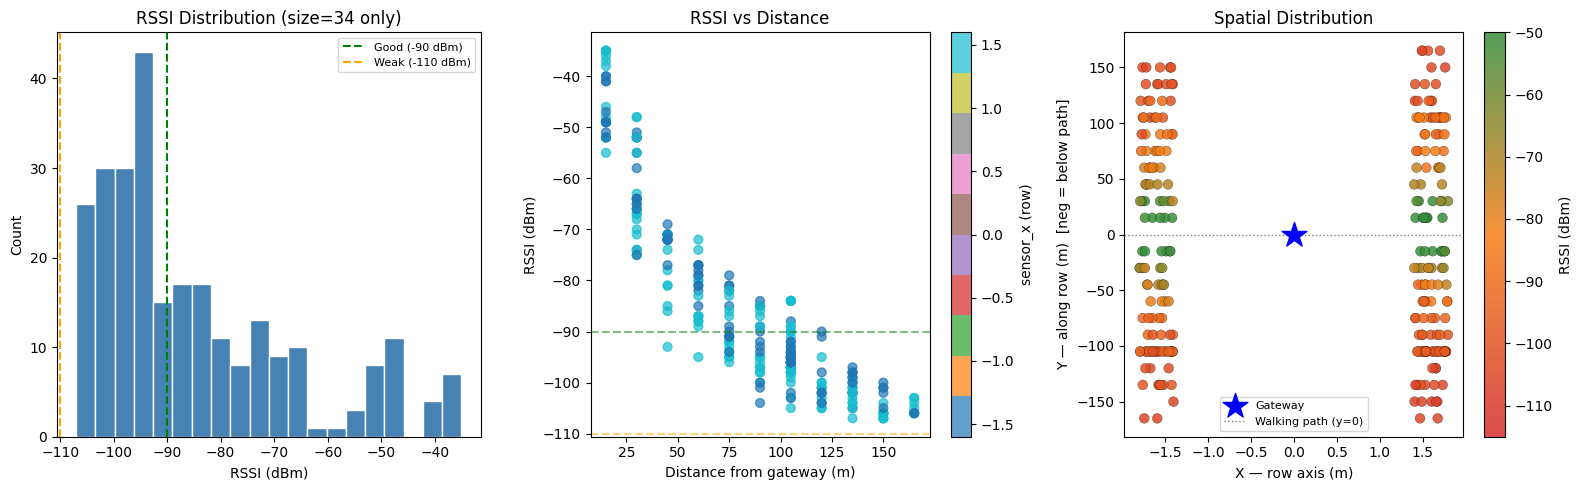

Saved: diagnostic_plots.png


In [28]:
# ── DIAGNOSTIC PLOTS ──────────────────────────────────────────────────────
cmap_rssi = LinearSegmentedColormap.from_list('rssi', ['#d32f2f', '#f57f17', '#388e3c'])
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. RSSI histogram
axes[0].hist(labeled['rssi'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(RSSI_GOOD, color='green',  linestyle='--', label=f'Good ({RSSI_GOOD} dBm)')
axes[0].axvline(RSSI_WEAK, color='orange', linestyle='--', label=f'Weak ({RSSI_WEAK} dBm)')
axes[0].set_xlabel('RSSI (dBm)')
axes[0].set_ylabel('Count')
axes[0].set_title('RSSI Distribution (size=34 only)')
axes[0].legend(fontsize=8)

# 2. RSSI vs distance, coloured by row
sc = axes[1].scatter(labeled['distance'], labeled['rssi'],
                     c=labeled['sensor_x'], cmap='tab10', alpha=0.7, s=40)
plt.colorbar(sc, ax=axes[1], label='sensor_x (row)')
axes[1].axhline(RSSI_GOOD, color='green',  linestyle='--', alpha=0.5)
axes[1].axhline(RSSI_WEAK, color='orange', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Distance from gateway (m)')
axes[1].set_ylabel('RSSI (dBm)')
axes[1].set_title('RSSI vs Distance')

# 3. Spatial map — one dot per packet coloured by RSSI
# Small x-jitter so overlapping points at the same row are visible
np.random.seed(42)
jitter = np.random.uniform(-0.2, 0.2, len(labeled))
sc2 = axes[2].scatter(
    labeled['sensor_x'] + jitter, labeled['sensor_y'],
    c=labeled['rssi'], cmap=cmap_rssi, vmin=-115, vmax=-50,
    s=50, edgecolors='k', linewidths=0.2, alpha=0.85
)
axes[2].scatter(GATEWAY_X, GATEWAY_Y, marker='*', s=350,
               color='blue', zorder=10, label='Gateway')
axes[2].axhline(0, color='grey', linestyle=':', lw=1, label='Walking path (y=0)')
plt.colorbar(sc2, ax=axes[2], label='RSSI (dBm)')
axes[2].set_xlabel('X — row axis (m)')
axes[2].set_ylabel('Y — along row (m)  [neg = below path]')
axes[2].set_title('Spatial Distribution')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('diagnostic_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: diagnostic_plots.png')